In [4]:
import scanpy as sc
import pycisTopic
from pycisTopic.cistopic_class import *
import pickle
import os
import anndata
import mudata
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import ArrowStyle
from scipy.stats import fisher_exact
import seaborn as sns
import glob
import PyComplexHeatmap as pch
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib_venn import venn2
from ast import literal_eval
from scipy.stats import hypergeom
from scipy.stats import pearsonr
import numpy as np
from scipy.stats import pearsonr, spearmanr
import warnings
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import SpectralCoclustering,SpectralBiclustering
from sklearn.metrics import consensus_score
from statsmodels.stats.multitest import multipletests
import glob as glob
from scenicplus.RSS import (regulon_specificity_scores, plot_rss)
from scenicplus.plotting.dotplot import heatmap_dotplot


In [41]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os

def build_organic_cluster_layout(graph, tf_list, gene_list):
    import random
    random.seed(42)
    np.random.seed(42)
    
    pos = {}
    
    # 步骤 1：宏观布局 - 将核心 TF 彻底推开
    if len(tf_list) == 1:
        pos[tf_list[0]] = np.array([0.0, 0.0])
    else:
        tf_radius = max(80, len(tf_list) * 20)
        angles = np.linspace(0, 2 * np.pi, len(tf_list), endpoint=False)
        for i, tf in enumerate(tf_list):
            pos[tf] = np.array([tf_radius * np.cos(angles[i]), tf_radius * np.sin(angles[i])])

    # 步骤 2：微观布局 - 手动制造紧凑但略微拉开的“星爆”簇
    for gene in gene_list:
        parents = list(graph.predecessors(gene))
        if len(parents) == 1:
            # 独有靶基因：紧紧围绕唯一的 TF
            center = pos[parents[0]]
            angle = np.random.uniform(0, 2 * np.pi)
            
            # 【修改点 1】调大半径范围（从 0.15~0.5 放大到 0.4~1.0）
            # 这样 TF 到 Gene 的连线就会明显变长，簇的整体视觉效果会稍微“松绑”
            r = np.random.uniform(0.6, 0.7) 
            pos[gene] = center + np.array([r * np.cos(angle), r * np.sin(angle)])
        elif len(parents) > 1:
            # 共享靶基因：拉到多个 TF 的几何中心
            center = np.mean([pos[p] for p in parents if p in pos], axis=0)
            noise = np.random.uniform(-0.1, 0.1, 2)
            pos[gene] = center + noise
        else:
            pos[gene] = np.array([0.0, 0.0])

    # 步骤 3：物理微调 (只允许基因动，TF不动)
    pos = nx.spring_layout(
        graph, 
        pos=pos,          
        fixed=tf_list,    # 锁定 TF 节点坐标
        k=0.08,           
        iterations=20,    
        seed=42
    )
    return pos

def visualize_regulatory_network(metadata_df, importance_col='importance', weight_col='importance_TF2G', figure_size=(7, 7),
                               top_n=100, output_html='figures/network.html', title='SCENIC+ Regulatory Network', df_deg=None):
    from pyvis.network import Network

    if metadata_df.empty:
        raise ValueError('metadata_df is empty after filtering.')

    if importance_col not in metadata_df.columns:
        raise KeyError(f'{importance_col} not found in metadata_df')

    if weight_col not in metadata_df.columns:
        metadata_df = metadata_df.copy()
        metadata_df[weight_col] = metadata_df[importance_col]

    df = metadata_df.sort_values(importance_col, ascending=False).head(top_n).copy()

    if df_deg is None:
        df_deg_plot = pd.DataFrame(columns=['gene', 'condition', 'de_coef'])
    else:
        df_deg_plot = df_deg.copy()
        if 'gene' not in df_deg_plot.columns:
            gene_col = next((col for col in ['Gene', 'targetgene', 'TF'] if col in df_deg_plot.columns), None)
            if gene_col is None:
                raise KeyError('df_deg must contain a gene-like column.')
            df_deg_plot = df_deg_plot.rename(columns={gene_col: 'gene'})
        if 'de_coef' not in df_deg_plot.columns:
            coef_col = next((col for col in ['de_coef', 'log2FC'] if col in df_deg_plot.columns), None)
            if coef_col is None:
                raise KeyError('df_deg must contain de_coef or log2FC.')
            df_deg_plot = df_deg_plot.rename(columns={coef_col: 'de_coef'})
        if 'condition' not in df_deg_plot.columns:
            df_deg_plot['condition'] = np.where(df_deg_plot['de_coef'] > 0, 'UP', 'DOWN')
        df_deg_plot['gene'] = df_deg_plot['gene'].astype(str).str.upper()
        df_deg_plot = df_deg_plot.sort_values('de_coef', key=lambda s: s.abs(), ascending=False).drop_duplicates('gene')

    df['TF'] = df['TF'].astype(str).str.upper()
    df['Gene'] = df['Gene'].astype(str).str.upper()

    G = nx.DiGraph()
    for _, row in df.iterrows():
        G.add_edge(
            row['TF'],
            row['Gene'],
            weight=row[weight_col],
            title=f"Weight: {row[weight_col]:.2f}"
        )

    def format_label(name):
        name = str(name).strip()
        return name[:1].upper() + name[1:].lower() if name else name

    degrees = dict(G.degree())
    max_degree = max(degrees.values()) if degrees else 1
    tf_nodes = sorted(df['TF'].unique())
    tf_node_set = set(tf_nodes)
    gene_nodes = sorted([node for node in G.nodes() if node not in tf_node_set])
    deg_lookup = df_deg_plot.set_index('gene')[['condition', 'de_coef']].to_dict('index') if not df_deg_plot.empty else {}

    node_colors = {}
    node_edge_colors = {}
    node_edge_widths = {}

    for node in G.nodes():
        deg_info = deg_lookup.get(node)
        if deg_info is not None and deg_info['condition'] == 'UP':
            fill_color = '#E86A33' if node in tf_node_set else '#F3A26D'
            edge_color = '#C9511C'
            edge_width = 3
        elif deg_info is not None and deg_info['condition'] == 'DOWN':
            fill_color = '#3A86C8' if node in tf_node_set else '#8EC0E6'
            edge_color = '#2C6BA0'
            edge_width = 3
        else:
            fill_color = 'lightgray'
            edge_color = 'lightgray'
            edge_width = 0

        node_colors[node] = fill_color
        node_edge_colors[node] = edge_color
        node_edge_widths[node] = edge_width

    plt.figure(figsize=figure_size)
    pos = build_organic_cluster_layout(G, tf_nodes, gene_nodes)    

    node_sizes = []
    for node in G.nodes():
        deg_info = deg_lookup.get(node)
        base_size = 260 if node in tf_node_set else 120
        degree_size = degrees[node] * (900 if node in tf_node_set else 380) / max_degree
        if deg_info is not None:
            fold_change = abs(deg_info['de_coef']) * (520 if node in tf_node_set else 320)
        else:
            fold_change = 0
        node_sizes.append(base_size + degree_size + fold_change)

    node_shapes = {node: 'h' if node in tf_node_set else 'o' for node in G.nodes()}
    for shape in set(node_shapes.values()):
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=[node for node in G.nodes() if node_shapes[node] == shape],
            node_shape=shape,
            node_color=[node_colors[node] for node in G.nodes() if node_shapes[node] == shape],
            edgecolors=[node_edge_colors[node] for node in G.nodes() if node_shapes[node] == shape],
            linewidths=[node_edge_widths[node] for node in G.nodes() if node_shapes[node] == shape],
            node_size=[node_sizes[index] for index, node in enumerate(G.nodes()) if node_shapes[node] == shape],
            alpha=0.92
        )

    # 绘制边
    for source, target, edge_data in G.edges(data=True):
        # 【修改点 2】将 arrowstyle 直接硬编码为 '-'，这样就会彻底取消箭头，变成纯直线
        nx.draw_networkx_edges(
            G, pos, edgelist=[(source, target)],
            width=1,
            edge_color='#8F8F8F',
            alpha=0.45,
            arrowstyle='-', 
            connectionstyle='arc3, rad=0.0'
        )

    import matplotlib.patheffects as path_effects
    tf_labels = {node: format_label(node) for node in tf_nodes if node in pos}
    gene_labels = {node: format_label(node) for node in gene_nodes if node in pos}
    tf_text_labels = nx.draw_networkx_labels(
        G, pos, labels=tf_labels, font_size=10, font_family='sans-serif',
        bbox=dict(facecolor='none', pad=0.1, edgecolor='none')
    )
    gene_text_labels = nx.draw_networkx_labels(
        G, pos, labels=gene_labels, font_size=7, font_family='sans-serif',
        bbox=dict(facecolor='none', pad=0.05, edgecolor='none')
    )
    for _, label in {**tf_text_labels, **gene_text_labels}.items():
        label.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='white'),
            path_effects.Normal()
        ])

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    output_dir = os.path.dirname(output_html)
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
    plt.savefig(output_html + '.png', dpi=300)
    plt.show()

    # Pyvis HTML 部分保持原样不变
    net = Network(height='800px', width='100%', directed=True)
    net.from_nx(G)
    for node in net.nodes:
        node['label'] = format_label(node['id'])
        if node['id'] in tf_node_set:
            node['shape'] = 'triangle'
            node['size'] = 28
        else:
            node['size'] = 16
    net.barnes_hut(gravity=-25000, central_gravity=0.15, spring_length=140, spring_strength=0.02, damping=0.95)
    net.show_buttons(filter_=['physics'])
    net.save_graph(output_html)
    print(f'Interactive visualization saved to {output_html}')

# Read the meta data 

In [5]:
if os.path.exists("/data2st2/junyi/output/stg1028/combined_ALL_meta.csv"):
    df_meta = pd.read_csv("/data2st2/junyi/output/stg1028/combined_ALL_meta.csv", index_col=0)
    df_meta.drop_duplicates(inplace=True)
else:
    df_meta = pd.DataFrame()
    h5ads = glob.glob('/data2st2/junyi/output/stg1028/*_4VN/*.h5ad')
    for h5ad in h5ads:
        adata = sc.read_h5ad(h5ad, backed='r')
        df_meta = pd.concat([df_meta, pd.DataFrame(adata.obs)], axis=0)
    df_meta.to_csv("/data2st2/junyi/output/stg1028/combined_ALL_meta.csv")
    df_meta.drop_duplicates(inplace=True)

/tmp/ipykernel_2543538/3001891177.py:2: DtypeWarning: Columns (20,56,57,58,67,68) have mixed types. Specify dtype option on import or set low_memory=False.


In [6]:
# Read the meta data and create a map between desired maps
df_meta['Region Subclass'] = df_meta['region'] + "_" + df_meta['celltype.L2']
df_meta_match = df_meta.drop_duplicates(subset=['Region Subclass'])
df_meta_match['ctname'] = df_meta_match['Region Subclass'].str.replace('/', '-').str.replace(' ', '_')

In [7]:
def gen_map_from_meta(df_meta_match=df_meta_match,iput_col='ctname',output_col='Region Subclass'):
    df_meta_match = df_meta_match.dropna(subset=[iput_col, output_col])
    df_meta_match = df_meta_match.drop_duplicates(subset=[iput_col, output_col])
    map_dict = dict(zip(df_meta_match[iput_col], df_meta_match[output_col]))
    return map_dict

In [8]:
df_tf_target_deg_hypergeom = pd.read_csv('/data2st2/junyi/output/stg1028/scenic_wilcoxon_all/scenic_wilcoxon_all_TF_regulon_deg_overlap_summary.csv')

In [9]:
df_deg_all = pd.read_excel("/data2st2/junyi/output/1-1 six_dataset_DEG_list_fdr_FC01_filtered_7region_rmMB 20251227.xlsx",sheet_name="all",index_col=0)


In [10]:
df_tf_target_deg_hypergeom_filtered = df_tf_target_deg_hypergeom[
    (df_tf_target_deg_hypergeom['hypergeom_p_up'] < 0.05) | (df_tf_target_deg_hypergeom['hypergeom_p_down'] < 0.05)
].copy()
df_deg_info = df_deg_all.copy()
df_deg_info['ctname'] = df_deg_all['Region'] + "_" + df_deg_all['Subclass']
df_deg_info['ctname'] = df_deg_info['ctname'].str.replace('/', '-')
df_deg_info['ctname'] = df_deg_info['ctname'].str.replace(' ', '_')
df_deg_info['TF'] = df_deg_info.index
df_deg_info['comparison'] = df_deg_info['Model'].str.replace(' ', '_')
df_deg_info['TF'] = df_deg_info['TF'].str.upper()
df_deg_info['Is_DEG'] = True
df_tf_target_deg_hypergeom_filtered['Direction'] = df_tf_target_deg_hypergeom_filtered['log2FC'].apply(lambda x: 'Up' if x > 0 else ('Down' if x < 0 else 'Ns'))
df_tf_target_deg_hypergeom_filtered = df_tf_target_deg_hypergeom_filtered.merge(
    df_deg_info.loc[:, ['log2FC', 'FDR', 'TF', 'comparison', 'ctname','Direction','Is_DEG']],
    on=['ctname', 'comparison','TF','Direction'],
    how='left',
    suffixes=('_scenic', '_deg')
)

df_tf_target_deg_hypergeom_filtered['TF_up'] = df_tf_target_deg_hypergeom_filtered['TF']
# Change only the first letter of TF to uppercase, rest is lower case
df_tf_target_deg_hypergeom_filtered['TF'] = df_tf_target_deg_hypergeom_filtered['TF'].str.lower().str.capitalize()

In [11]:
df_tf_target_deg_hypergeom_filtered['nlogp_scenic'] = -1 * np.log10(df_tf_target_deg_hypergeom_filtered['FDR_scenic'] + 1e-300)
df_tf_target_deg_hypergeom_filtered['nlogp_deg'] = -1 * np.log10(df_tf_target_deg_hypergeom_filtered['FDR_deg'] + 1e-300)


In [21]:
available_ctnames = sorted(df_tf_target_deg_hypergeom['ctname'].dropna().unique())
selected_ctnames = [available_ctnames[0]]
selected_comparison = None

if len(selected_ctnames) != 1:
    raise ValueError('Please select exactly one ctname.')

In [43]:
available_ctnames

['AMY_AMY_Cav1_Frmpd1_Glut',
 'AMY_AMY_Ccdc3_Acvr1c_Glut',
 'AMY_AMY_Cdh23_Hmcn1_Glut',
 'AMY_AMY_Crhbp_Maf_GABA',
 'AMY_AMY_Esr2_Gldn_GABA',
 'AMY_AMY_Fign_Ostm1_GABA',
 'AMY_AMY_Foxp2_Penk_GABA',
 'AMY_AMY_Hcrtr2_Hapln1_GABA',
 'AMY_AMY_Maf_Pthlh_GABA',
 'AMY_AMY_Meis1_Abi3bp_Glut',
 'AMY_AMY_Ndnf_Lamp5_GABA',
 'AMY_AMY_Npas1_Rgs12_GABA',
 'AMY_AMY_Piezo2_Cpa6_Glut',
 'AMY_AMY_Rai14_Six3_GABA',
 'AMY_AMY_Rorb_Smoc1_Glut',
 'AMY_AMY_Rspo2_Gm11639_Glut',
 'AMY_AMY_Tcf7l2_Gm20713_Glut',
 'AMY_AMY_Trabd2b_Coch_Glut',
 'AMY_AMY_Zbtb7c_Vwa5b1_Glut',
 'AMY_AMY_Zfhx3_Glra1_Glut',
 'AMY_AMY_Zfhx4_Pde7b_GABA',
 'AMY_Arachnoid_Barrier_cell',
 'AMY_Astrocyte-1',
 'AMY_Astrocyte-2',
 'AMY_Astrocyte-3',
 'AMY_Astrocyte-4',
 'AMY_COP',
 'AMY_Endothelial_cell',
 'AMY_Ependymal_cell',
 'AMY_MFOL',
 'AMY_MOL-1',
 'AMY_MOL-2',
 'AMY_MOL-3',
 'AMY_Microglia-1',
 'AMY_Microglia-2',
 'AMY_OPC',
 'AMY_VLMC',
 'HPF_Arachnoid_Barrier_cell',
 'HPF_Astrocyte-1',
 'HPF_Astrocyte-2',
 'HPF_Astrocyte-3',
 'HPF_As

,ctname,comparison,TF,Gene,importance,importance_TF2G,edge_direction
0,HPF_HPF_DG_GC_Glut,CUSUS_M,NPDC1,ACTB,1,1,UP
1,HPF_HPF_DG_GC_Glut,CUSUS_M,NPDC1,ACTG1,1,1,UP
2,HPF_HPF_DG_GC_Glut,CUSUS_M,NPDC1,ALDOA,1,1,UP
3,HPF_HPF_DG_GC_Glut,CUSUS_M,NPDC1,APLP1,1,1,UP
4,HPF_HPF_DG_GC_Glut,CUSUS_M,NPDC1,ATP1A1,1,1,UP


ctname: HPF_HPF_DG_GC_Glut
comparison: all_comparisons
n_edges: 188
n_tfs: 10
n_genes: 104


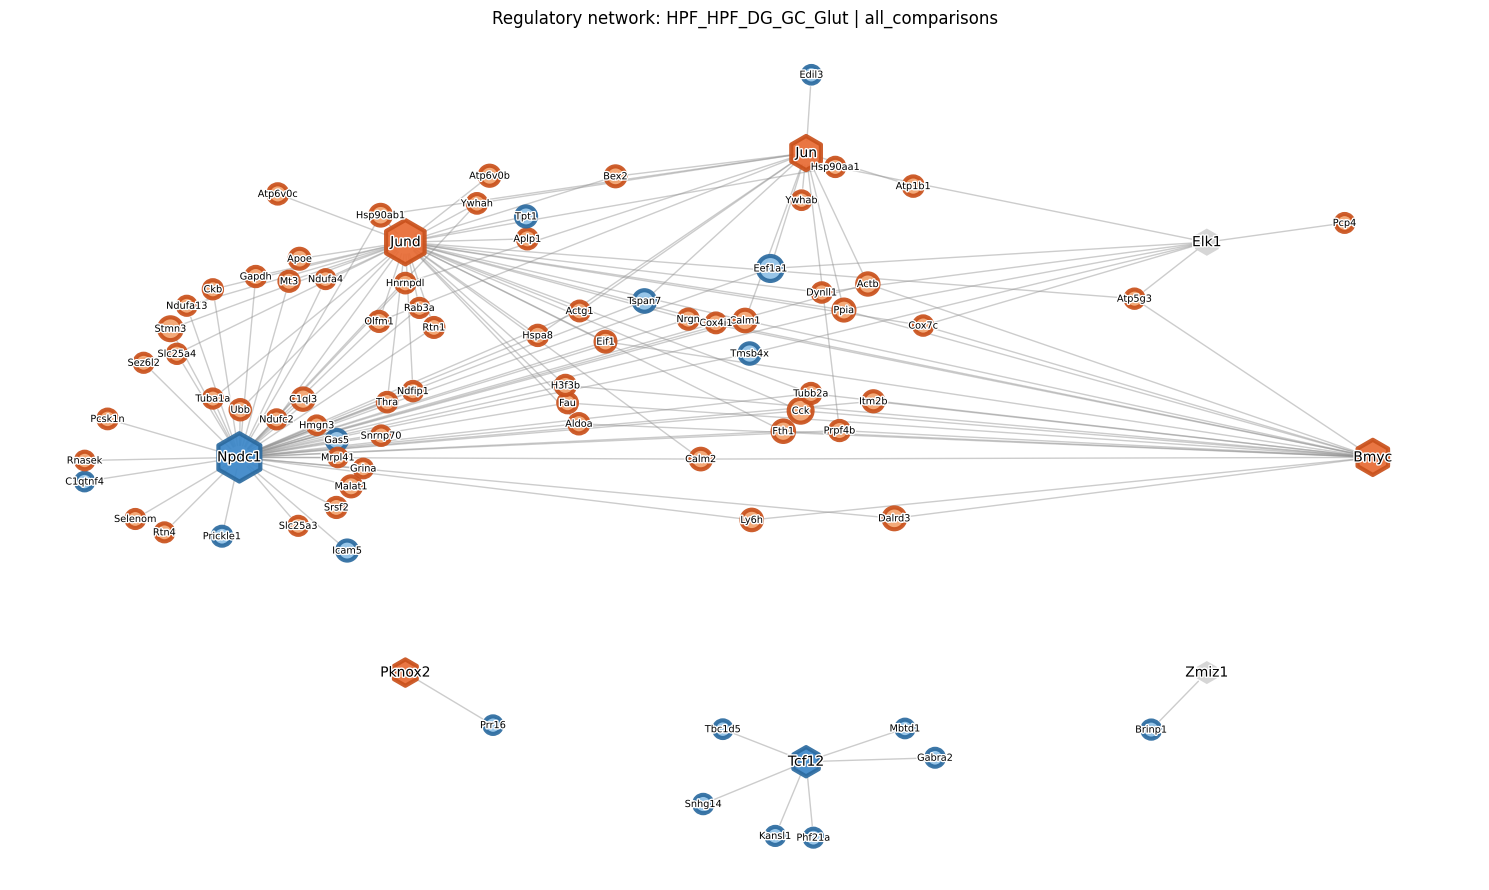

Interactive visualization saved to figures/HPF_HPF_DG_GC_Glut_all_comparisons_regulatory_network.html


In [49]:
# Select celltype name
selected_ctname = 'HPF_HPF_DG_GC_Glut'
network_source = df_tf_target_deg_hypergeom[df_tf_target_deg_hypergeom['ctname'] == selected_ctname].copy()
network_source = network_source[network_source.comparison == 'CUSUS_M']
network_source = pd.concat([
network_source.sort_values('n_up_overlap',ascending=False).head(5),
network_source.sort_values('n_down_overlap',ascending=False).head(5)
])
network_source

if network_source.empty:
    raise ValueError(f'No rows found for ctname: {selected_ctname}')

if selected_comparison is not None:
    network_source = network_source[network_source['comparison'] == selected_comparison].copy()

if network_source['ctname'].nunique() != 1:
    raise ValueError('Network input still contains multiple ctname values.')

network_source = network_source[
    (network_source['n_up_overlap'] > 0) | (network_source['n_down_overlap'] > 0)
].copy()

def split_gene_list(value):
    if pd.isna(value) or value == '':
        return []
    return [gene.strip().upper() for gene in str(value).split(',') if gene.strip()]

edge_records = []
for _, row in network_source.iterrows():
    tf_name = str(row['TF']).upper()
    for gene in split_gene_list(row['up_deg_list']):
        edge_records.append({
            'ctname': row['ctname'],
            'comparison': row['comparison'],
            'TF': tf_name,
            'Gene': gene,
            'importance': 1,
            'importance_TF2G': 1,
            'edge_direction': 'UP'
        })
    for gene in split_gene_list(row['down_deg_list']):
        edge_records.append({
            'ctname': row['ctname'],
            'comparison': row['comparison'],
            'TF': tf_name,
            'Gene': gene,
            'importance': 1,
            'importance_TF2G': -1,
            'edge_direction': 'DOWN'
        })

network_edges = pd.DataFrame(edge_records)
if network_edges.empty:
    raise ValueError(f'No TF-gene edges found for ctname: {selected_ctname}')

network_edges = network_edges.drop_duplicates(['ctname', 'comparison', 'TF', 'Gene', 'edge_direction']).copy()

df_deg_network = df_deg_all.copy()
df_deg_network['ctname'] = df_deg_network['Region'] + '_' + df_deg_network['Subclass']
df_deg_network['ctname'] = df_deg_network['ctname'].str.replace('/', '-', regex=False)
df_deg_network['ctname'] = df_deg_network['ctname'].str.replace(' ', '_', regex=False)
df_deg_network['comparison'] = df_deg_network['Model'].str.replace(' ', '_', regex=False)

gene_col = next((col for col in ['gene', 'Gene', 'targetgene'] if col in df_deg_network.columns), None)
if gene_col is None:
    df_deg_network['gene'] = df_deg_network.index.astype(str)
else:
    df_deg_network['gene'] = df_deg_network[gene_col].astype(str)

coef_col = next((col for col in ['de_coef', 'log2FC'] if col in df_deg_network.columns), None)
if coef_col is None:
    raise KeyError('df_deg_all must contain de_coef or log2FC.')

df_deg_network = df_deg_network[df_deg_network['ctname'] == selected_ctname].copy()
if selected_comparison is not None:
    df_deg_network = df_deg_network[df_deg_network['comparison'] == selected_comparison].copy()

df_deg_network['gene'] = df_deg_network['gene'].str.upper()
df_deg_network['de_coef'] = df_deg_network[coef_col]
df_deg_network['condition'] = np.where(df_deg_network['de_coef'] > 0, 'UP', 'DOWN')
df_deg_network = df_deg_network[['gene', 'de_coef', 'condition']].drop_duplicates('gene')

comparison_label = selected_comparison if selected_comparison is not None else 'all_comparisons'
display(network_edges.head())
print(f'ctname: {selected_ctname}')
print(f'comparison: {comparison_label}')
print(f'n_edges: {len(network_edges)}')
print(f'n_tfs: {network_edges["TF"].nunique()}')
print(f'n_genes: {network_edges["Gene"].nunique()}')

visualize_regulatory_network(
    network_edges,
    importance_col='importance',
    weight_col='importance_TF2G',
    figure_size=(15, 9),
    top_n=min(150, len(network_edges)),
    output_html=f'figures/{selected_ctname}_{comparison_label}_regulatory_network.html',
    title=f'Regulatory network: {selected_ctname} | {comparison_label}',
    df_deg=df_deg_network
)